<a href="https://colab.research.google.com/github/venkatR-code01/malaria-classifier/blob/main/01_load_and_explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"Step 1: Load the dataset" → Load the dataset

In [1]:
!pip install importlib_resources
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

!pip install --upgrade protobuf

dataset, info = tfds.load('malaria', split='train', with_info=True, as_supervised=True)

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.H0RIXK_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman

"Step 2: Check what the labels mean" → Check what the labels mean

In [2]:
label_names = info.features['label'].names
print("Labels:", label_names)
print("Total photos:", info.splits['train'].num_examples)

Labels: ['parasitized', 'uninfected']
Total photos: 27558


"Step 3: Look at the cells" → Look at the cells

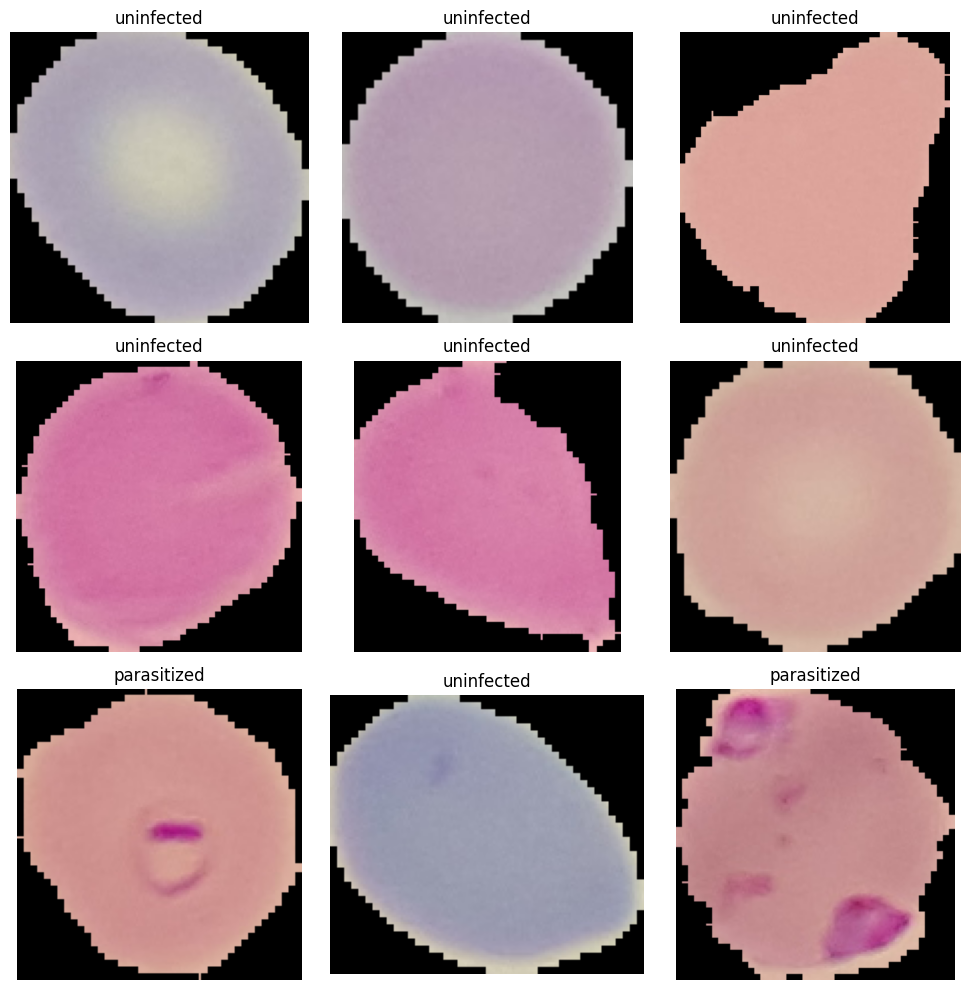

In [3]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(dataset.shuffle(1000, seed=42).take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(label_names[label.numpy()])
    plt.axis('off')
plt.tight_layout()
plt.show()